# Explorativní analýza
Pro analýzu byla použita datová sada Stroke Prediction Dataset ze stránky Kaggle.com (https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset?resource=download).
## Prozkoumání atributů
Nejprve načteme data z csv souboru do pandas dataframe. 


In [161]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df = df.drop(columns="id")
df["hypertension"] = df["hypertension"].astype("str")
df["heart_disease"] = df["heart_disease"].astype("str")
df["stroke"] = df["stroke"].astype("str")

Provedeme analýzu dat jako celek. Vypíšeme si datové typy jednotlivých atribůtu a pár dat od každého pro základní pochopení dat. 

In [162]:
print("Informace o datech:")
print(df.info())

print("Ukázka dat:")
print(df.head())


Informace o datech:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   object 
 3   heart_disease      5110 non-null   object 
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   object 
dtypes: float64(3), object(8)
memory usage: 439.3+ KB
None
Ukázka dat:
   gender   age hypertension heart_disease ever_married      work_type  \
0    Male  67.0            0             1          Yes        Private   
1  Female  61.0            0  

Dále si zobrazíme souhrné statistiky o datech pro získání ještě lepší představi o datech.

In [163]:
print("Popisná statistika číselných atributů:")
print(df[["age", "avg_glucose_level", "bmi"]].describe().T)
print("---------------------------------------------------------------------")
print("Popisná statistika kategorických atributů:")
# add to kategoric also hypertension    
print(df.describe(include=['object']).T)

Popisná statistika číselných atributů:
                    count        mean        std    min     25%     50%  \
age                5110.0   43.226614  22.612647   0.08  25.000  45.000   
avg_glucose_level  5110.0  106.147677  45.283560  55.12  77.245  91.885   
bmi                4909.0   28.893237   7.854067  10.30  23.500  28.100   

                      75%     max  
age                 61.00   82.00  
avg_glucose_level  114.09  271.74  
bmi                 33.10   97.60  
---------------------------------------------------------------------
Popisná statistika kategorických atributů:
               count unique           top  freq
gender          5110      3        Female  2994
hypertension    5110      2             0  4612
heart_disease   5110      2             0  4834
ever_married    5110      2           Yes  3353
work_type       5110      5       Private  2925
Residence_type  5110      2         Urban  2596
smoking_status  5110      4  never smoked  1892
stroke          511

## Grafy

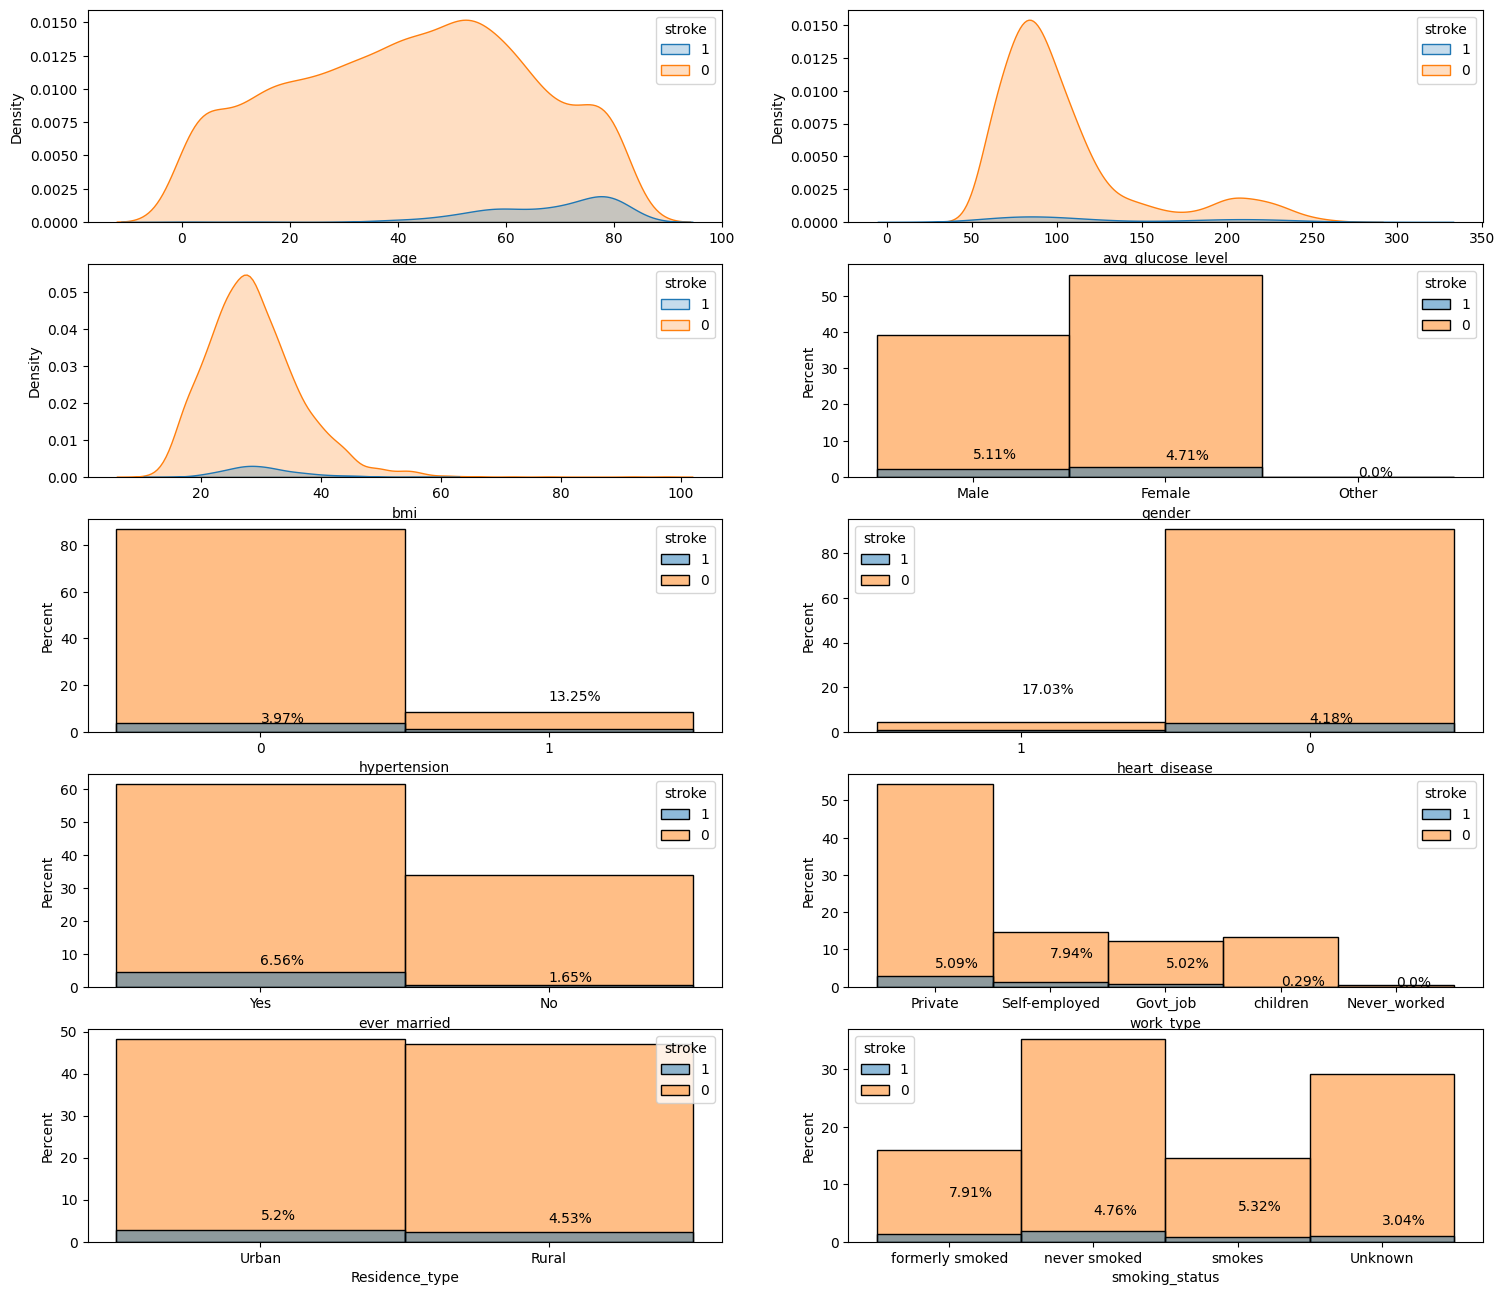

In [164]:
import numpy as np
fig, ax = plt.subplots(5, 2, figsize=(18, 16))
ax = ax.flatten()

numerical = ["age", "avg_glucose_level", "bmi"]
categorical = ["gender", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "smoking_status"]

# Numerical
for idx, attr in enumerate(numerical):
    sns.kdeplot(data=df, x=attr, hue="stroke", fill=True, ax=ax[idx])
# Categorical
for idx, attr in enumerate(categorical, start=3):
    sns.histplot(data=df, x=attr, hue="stroke", fill=True, ax=ax[idx], stat="percent")


    categories = [tick.get_text() for tick in ax[idx].get_xticklabels()]
    for category in categories:
        perc = df[(df[attr] == category) & (df['stroke'] == "1")].shape[0]/df[df[attr] == category].shape[0]
        x_pos = list(categories).index(category)
        ax[idx].text(
            x=x_pos,
            y=perc*100,
            s=f"{str(np.round(perc*100, decimals=2))}%"
        )



## Odlehlé hodnoty
Nejdříve provedeme analýzu numerických odlehlých hodnot a po pomocí IQR a pomocí Z-score. 

In [165]:


# Detekce pomocí IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Detekce pomocí Z-Score
def detect_outliers_zscore(df, column, threshold=3):
    col_data = df[column].dropna()
    z_scores = np.abs(stats.zscore(col_data))
    outliers = col_data[z_scores > threshold]
    return outliers


for col in [['age', 'Věk'], ['avg_glucose_level', 'Průměrná hladina glukózy'], ['bmi', 'BMI']]:
    print(f"{col[1]}: ")
    outliers_iqr = detect_outliers_iqr(df, col[0])
    print(" Pomocí IQR")
    print(f"  Počet nalezených odlehlých hodnot: {len(outliers_iqr)}")
    print(f"  Ukázka hodnot: {outliers_iqr[col[0]].values[:5]}")
    
    outliers_z = detect_outliers_zscore(df, col[0])
    print("Pomocí Z-Score")
    print(f"  Počet nalezených odlehlých hodnot: {len(outliers_z)}")
    print(f"  Ukázka hodnot: {outliers_z.values[:5]}")

    

Věk: 
 Pomocí IQR
  Počet nalezených odlehlých hodnot: 0
  Ukázka hodnot: []
Pomocí Z-Score
  Počet nalezených odlehlých hodnot: 0
  Ukázka hodnot: []
Průměrná hladina glukózy: 
 Pomocí IQR
  Počet nalezených odlehlých hodnot: 627
  Ukázka hodnot: [228.69 202.21 171.23 174.12 186.21]
Pomocí Z-Score
  Počet nalezených odlehlých hodnot: 49
  Ukázka hodnot: [252.72 243.58 259.63 249.31 263.32]
BMI: 
 Pomocí IQR
  Počet nalezených odlehlých hodnot: 110
  Ukázka hodnot: [48.9 56.6 50.1 54.6 60.9]
Pomocí Z-Score
  Počet nalezených odlehlých hodnot: 58
  Ukázka hodnot: [56.6 54.6 60.9 54.7 64.8]


In [166]:

# Detekce pomocí IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

# Detekce pomocí Z-Score
def detect_outliers_zscore(df, column, threshold=3):
    col_data = df[column].dropna()
    z_scores = np.abs(stats.zscore(col_data))
    outliers = col_data[z_scores > threshold]
    return outliers

columns_to_check = ['avg_glucose_level', 'bmi']


print(f"Level glukozy: ")
outliers_iqr = detect_outliers_iqr(df, 'avg_glucose_level')
print("Pomocí IQR")
print(f" Počet nalezených odlehlých hodnot: {len(outliers_iqr)}")
print(f" Ukázka hodnot: {outliers_iqr['avg_glucose_level'].values[:5]}")

outliers_z = detect_outliers_zscore(df, 'avg_glucose_level')
print("Pomocí Z-Score")
print(f" Počet nalezených odlehlých hodnot: {len(outliers_z)}")
print(f" Ukázka hodnot: {outliers_z.values[:5]}")

print(f"BMI: ")
outliers_iqr = detect_outliers_iqr(df, 'bmi')
print("Pomocí IQR")
print(f" Počet nalezených odlehlých hodnot: {len(outliers_iqr)}")
print(f" Ukázka hodnot: {outliers_iqr['bmi'].values[:5]}")

outliers_z = detect_outliers_zscore(df, 'bmi')
print("Pomocí Z-Score")
print(f" Počet nalezených odlehlých hodnot: {len(outliers_z)}")
print(f" Ukázka hodnot: {outliers_z.values[:5]}")

    

Level glukozy: 
Pomocí IQR
 Počet nalezených odlehlých hodnot: 627
 Ukázka hodnot: [228.69 202.21 171.23 174.12 186.21]
Pomocí Z-Score
 Počet nalezených odlehlých hodnot: 49
 Ukázka hodnot: [252.72 243.58 259.63 249.31 263.32]
BMI: 
Pomocí IQR
 Počet nalezených odlehlých hodnot: 110
 Ukázka hodnot: [48.9 56.6 50.1 54.6 60.9]
Pomocí Z-Score
 Počet nalezených odlehlých hodnot: 58
 Ukázka hodnot: [56.6 54.6 60.9 54.7 64.8]


Vidíme že IQR nalezlo velké množství hodnot vzhledem k velikosti celé datové sadě a tedy Z-score se jeví pro detekci jako lepší řešení. 

Dále provedeme analýzu odlehlých hodnot u kategorických atributů a to pomocí histogramů.

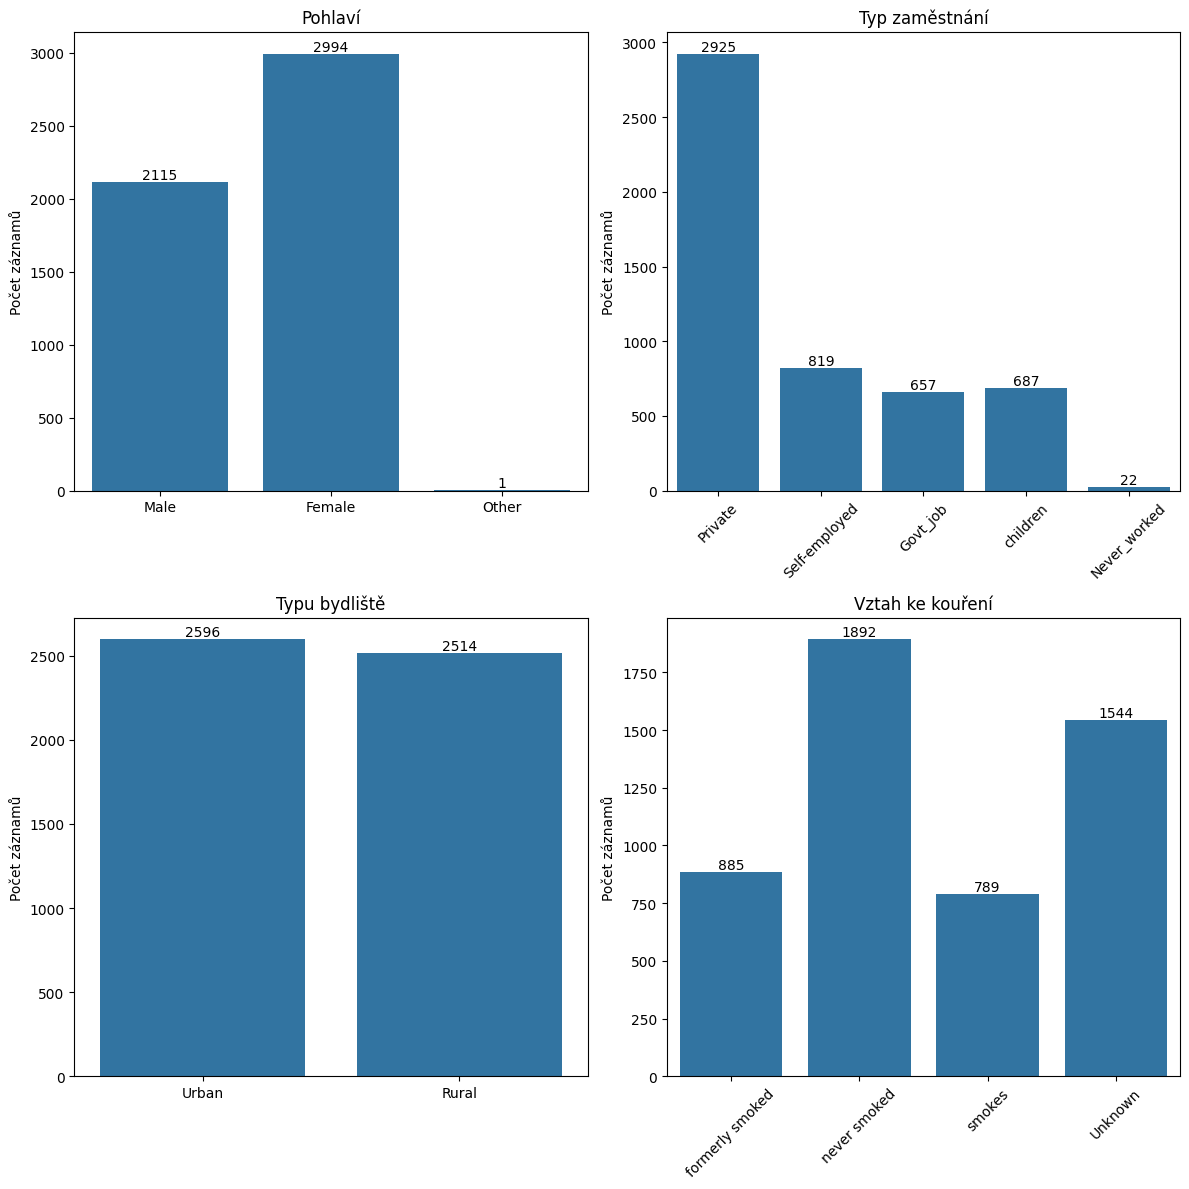

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

sns.countplot(data=df, x='gender', ax=axes[0, 0])
axes[0, 0].set_title("Pohlaví")
axes[0, 0].set_ylabel('Počet záznamů')

sns.countplot(data=df, x='work_type', ax=axes[0, 1])
axes[0, 1].set_title("Typ zaměstnání")
axes[0, 1].set_ylabel('Počet záznamů')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Residence_type', ax=axes[1, 0])
axes[1, 0].set_title("Typu bydliště")
axes[1, 0].set_ylabel('Počet záznamů')

sns.countplot(data=df, x='smoking_status', ax=axes[1, 1])
axes[1, 1].set_title("Vztah ke kouření")
axes[1, 1].set_ylabel('Počet záznamů')
axes[1, 1].tick_params(axis='x', rotation=45)

for ax in axes.flatten():
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

# Úprava datové sady

## Vyřešení chybějících hodnot

Pro vyřešení chybějících hodnotu jsou použity 2 metody a to odstranění zaznamů s chybějící hodnotou a nebo doplnění chybějících hodnot střední hodnotou.
V df_remove_missing je uložena kopie DF ve které jsou záznamy z chybějící BMI hodnotou BMI odstraněny.
Pro df používaný dále provodeme doplnění pomocí střední hodnoty. 

In [168]:
df_remove_missing = df.dropna(subset=['bmi'])
print(f"Počet záznamů po odstranění chybějících hodnot v 'bmi': {len(df_remove_missing)}")


df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
print(f"Počet záznamů po odstranění chybějících hodnot v 'bmi': {len(df)}")


Počet záznamů po odstranění chybějících hodnot v 'bmi': 4909
Počet záznamů po odstranění chybějících hodnot v 'bmi': 5110


## Odstranění odlehlých hodnot
Pro odstranění odlehlých hodnot u numerických atributů bylo použito Z-score. Kategorické atributy s odlehlými hodnotamy byly odstraněny.

In [ ]:
# remove numerical outliers using z-score
columns_to_check = ['avg_glucose_level', 'bmi']
for col in columns_to_check:
    z_scores = np.abs(stats.zscore(df[col]))
    df = df[z_scores <= 3]
print(f"Počet záznamů po odstranění odlehlých hodnot numerických atributů: {len(df)}")


Počet záznamů po odstranění odlehlých hodnot numerických atributů: 5002
